# Sesión 02 — Modelos de Clasificación
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Estudiante:** Tomas Rivera Davis Andriy  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

---

## Objetivo
Implementar, comparar y analizar cuatro modelos fundamentales de clasificación supervisada — **Regresión Logística, Árbol de Decisión, SVM y KNN** — sobre el dataset **AI vs Human Academic Writing** (Kaggle), evaluando sus fortalezas, limitaciones y sensibilidad al preprocesamiento.

## 1. Configuración del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    accuracy_score, f1_score, roc_auc_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

rs = 42
print('entorno configurado correctamente.')

entorno configurado correctamente.


---
## 2. Carga y comprensión del dataset

Utilizamos el **AI vs Human Academic Writing Dataset** (Razan Ihab Abdellatif, Kaggle). Es un dataset **sintético** con 10,200 entregas académicas y 20 columnas que combinan métricas lingüísticas (riqueza de vocabulario, nivel de lectura, errores gramaticales) con telemetría de escritura (tiempo de edición, velocidad de tipeo, revisiones).

La variable objetivo es **`Is_AI_Assisted`**, que ya es binaria:
- **Clase 1 (IA):** la entrega fue asistida por IA
- **Clase 0 (Humano):** la entrega fue escrita por una persona

El dataset trae imperfecciones a propósito, que hay que tratar antes de modelar:
- **Desbalance:** ~85.5% humano vs ~14.5% IA
- **Valores faltantes** en cinco columnas de telemetría (`Editing_Time`, `Revision_Count`, `Typing_Speed`, `Plagiarism_Score`, `Citation_Count`)
- **~2% de filas duplicadas** exactas
- **Outliers** extremos en tiempos de edición, velocidad de tipeo y errores gramaticales

> **Nota:** el código busca un `.csv` local que contenga la columna `Is_AI_Assisted`; si no lo encuentra, descarga el dataset con `kagglehub`. Para usar la descarga automática, instala antes `kagglehub` con `pip install kagglehub`. En Colab también puedes subir el archivo (`aivshmdata.csv`) al panel de archivos.

In [2]:
import glob
import os

rutas = list(dict.fromkeys(
    glob.glob('*.csv') + glob.glob('**/*.csv', recursive=True)
    + glob.glob('/content/**/*.csv', recursive=True)
))
df = None

for r in rutas:
    try:
        tmp = pd.read_csv(r)
    except (UnicodeDecodeError, pd.errors.ParserError):
        continue
    if 'Is_AI_Assisted' in tmp.columns:
        df = tmp
        print('archivo:', r)
        break

if df is None:
    import kagglehub
    ruta_dataset = kagglehub.dataset_download(
        'razanihababdellatif/ai-vs-human-academic-writing-dataset'
    )
    rutas = glob.glob(os.path.join(ruta_dataset, '**', '*.csv'), recursive=True)
    for r in rutas:
        tmp = pd.read_csv(r)
        if 'Is_AI_Assisted' in tmp.columns:
            df = tmp
            print('archivo descargado:', r)
            break

if df is None:
    raise FileNotFoundError(
        'No se encontró un CSV con la columna Is_AI_Assisted. '
        'Comprueba el dataset o su descarga desde Kaggle.'
    )

print(f'dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas')
df.head()

100%|██████████| 354k/354k [00:00<00:00, 678kB/s]

Extracting files...
archivo descargado: C:\Users\river\.cache\kagglehub\datasets\razanihababdellatif\ai-vs-human-academic-writing-dataset\versions\1\ai_writing_detection_dataset.csv
dataset cargado: 10200 registros, 20 columnas


,Student_ID,Submission_Type,Academic_Level,Primary_Language,Word_Count,Average_Sentence_Length,Grammar_Errors,Vocabulary_Richness,Passive_Voice_Ratio,Reading_Level,Editing_Time,Revision_Count,Typing_Speed,Plagiarism_Score,Citation_Count,Punctuation_Density,Sentence_Complexity,Font_Family,Submission_Hour,Is_AI_Assisted
0,16959e76,Lab_Report,Postgraduate,Native,1552,16.90,8,0.62,0.11,11.85,129.05,16.0,24.70,3.02,0.0,0.08,2.01,Arial,18,0
1,0a304e7f,Research_Paper,Undergraduate,Native,950,16.71,5,0.47,0.31,10.34,236.60,23.0,38.84,1.71,15.0,0.07,1.72,Helvetica,15,0
2,6e629f9f,Essay,Undergraduate,Non_Native,1103,22.10,1,0.76,0.38,14.35,4.72,4.0,0.00,0.41,0.0,0.08,2.35,Arial,17,1
3,16334d32,Essay,Postgraduate,Native,1189,20.00,7,0.61,0.26,10.93,NaN,24.0,41.92,3.06,5.0,0.05,1.68,Times New Roman,5,0
4,54d8e254,Essay,Undergraduate,Native,1035,22.67,2,0.80,0.33,15.30,16.82,2.0,0.00,2.78,1.0,0.09,2.90,Helvetica,8,1


In [3]:
print(df.dtypes)
df.describe().T.round(2)

Student_ID                     str
Submission_Type                str
Academic_Level                 str
Primary_Language               str
Word_Count                   int64
Average_Sentence_Length    float64
Grammar_Errors               int64
Vocabulary_Richness        float64
Passive_Voice_Ratio        float64
Reading_Level              float64
Editing_Time               float64
Revision_Count             float64
Typing_Speed               float64
Plagiarism_Score           float64
Citation_Count             float64
Punctuation_Density        float64
Sentence_Complexity        float64
Font_Family                    str
Submission_Hour              int64
Is_AI_Assisted               int64
dtype: object


,count,mean,std,min,25%,50%,75%,max
Word_Count,10200.0,1201.67,395.17,300.00,925.00,1196.00,1471.00,2588.00
Average_Sentence_Length,10200.0,16.94,4.64,5.00,13.62,17.08,20.64,33.62
Grammar_Errors,10200.0,7.34,5.05,0.00,5.00,7.00,9.00,78.00
Vocabulary_Richness,10200.0,0.62,0.10,0.29,0.55,0.62,0.70,0.90
Passive_Voice_Ratio,10200.0,0.20,0.10,0.00,0.14,0.20,0.27,0.52
Reading_Level,10200.0,11.48,2.54,5.00,9.70,11.58,13.42,20.00
Editing_Time,9311.0,161.76,110.51,1.00,111.70,167.66,213.56,1493.40
Revision_Count,8687.0,21.54,9.36,0.00,19.00,24.00,27.00,45.00
Typing_Speed,9197.0,164.19,354.84,0.00,34.74,46.50,59.35,1200.00
Plagiarism_Score,9387.0,7.17,7.68,0.00,1.84,4.64,9.84,72.33


### 2.1 Calidad de datos: nulos y duplicados

In [3]:
nul = df.isna().sum()
nul = nul[nul > 0].to_frame('nulos')
nul['%'] = (nul['nulos'] / len(df) * 100).round(1)
print(nul)

print(f'\nduplicados exactos: {df.duplicated().sum()}')
df = df.drop_duplicates().reset_index(drop=True)
print(f'registros tras eliminar duplicados: {df.shape[0]}')

                  nulos     %
Editing_Time        889   8.7
Revision_Count     1513  14.8
Typing_Speed       1003   9.8
Plagiarism_Score    813   8.0
Citation_Count      993   9.7

duplicados exactos: 200
registros tras eliminar duplicados: 10000


Los duplicados se eliminan **antes** del split: si una misma fila quedara en train y en test, el modelo "vería" parte del examen y las métricas saldrían infladas. Los nulos, en cambio, **no se imputan aquí**: se imputarán dentro del `Pipeline` para que la mediana se calcule solo con los datos de entrenamiento de cada fold (sin fuga de información).

### 2.2 Variable objetivo

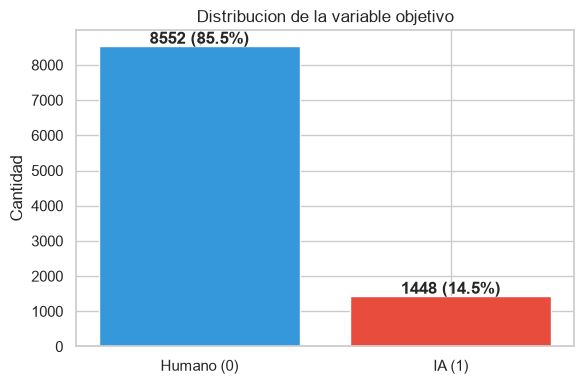

ratio de desbalance: 5.9:1 (humano vs ia)


In [4]:
tgt = 'Is_AI_Assisted'
cnt = df[tgt].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Humano (0)', 'IA (1)'], cnt.values, color=['#3498db', '#e74c3c'])
for i, v in enumerate(cnt.values):
    ax.text(i, v + 50, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Distribucion de la variable objetivo')
ax.set_ylabel('Cantidad')
plt.tight_layout()
plt.show()

print(f'ratio de desbalance: {cnt[0]/cnt[1]:.1f}:1 (humano vs ia)')

---
## 3. Análisis exploratorio orientado a clasificación

In [5]:
# 3.1  Mediana por clase (robusta a los outliers)
nums = df.select_dtypes(include='number').columns.drop(tgt)
cats = [c for c in df.select_dtypes(exclude='number').columns if c != 'Student_ID']

comp = df.groupby(tgt)[nums].median().T
comp.columns = ['Humano (0)', 'IA (1)']
comp['Diferencia %'] = ((comp['IA (1)'] - comp['Humano (0)']) / comp['Humano (0)'] * 100).round(1)
comp = comp.replace([np.inf, -np.inf], np.nan)
comp.style.background_gradient(subset=['Diferencia %'], cmap='RdYlGn')

,Humano (0),IA (1),Diferencia %
Word_Count,1201.000000,1178.000000,-1.900000
Average_Sentence_Length,16.080000,21.980000,36.700000
Grammar_Errors,8.000000,1.000000,-87.500000
Vocabulary_Richness,0.600000,0.750000,25.000000
Passive_Voice_Ratio,0.180000,0.350000,94.400000
Reading_Level,11.055000,14.040000,27.000000
Editing_Time,180.530000,10.070000,-94.400000
Revision_Count,25.000000,2.000000,-92.000000
Typing_Speed,45.040000,1200.000000,2564.300000
Plagiarism_Score,5.380000,1.800000,-66.500000


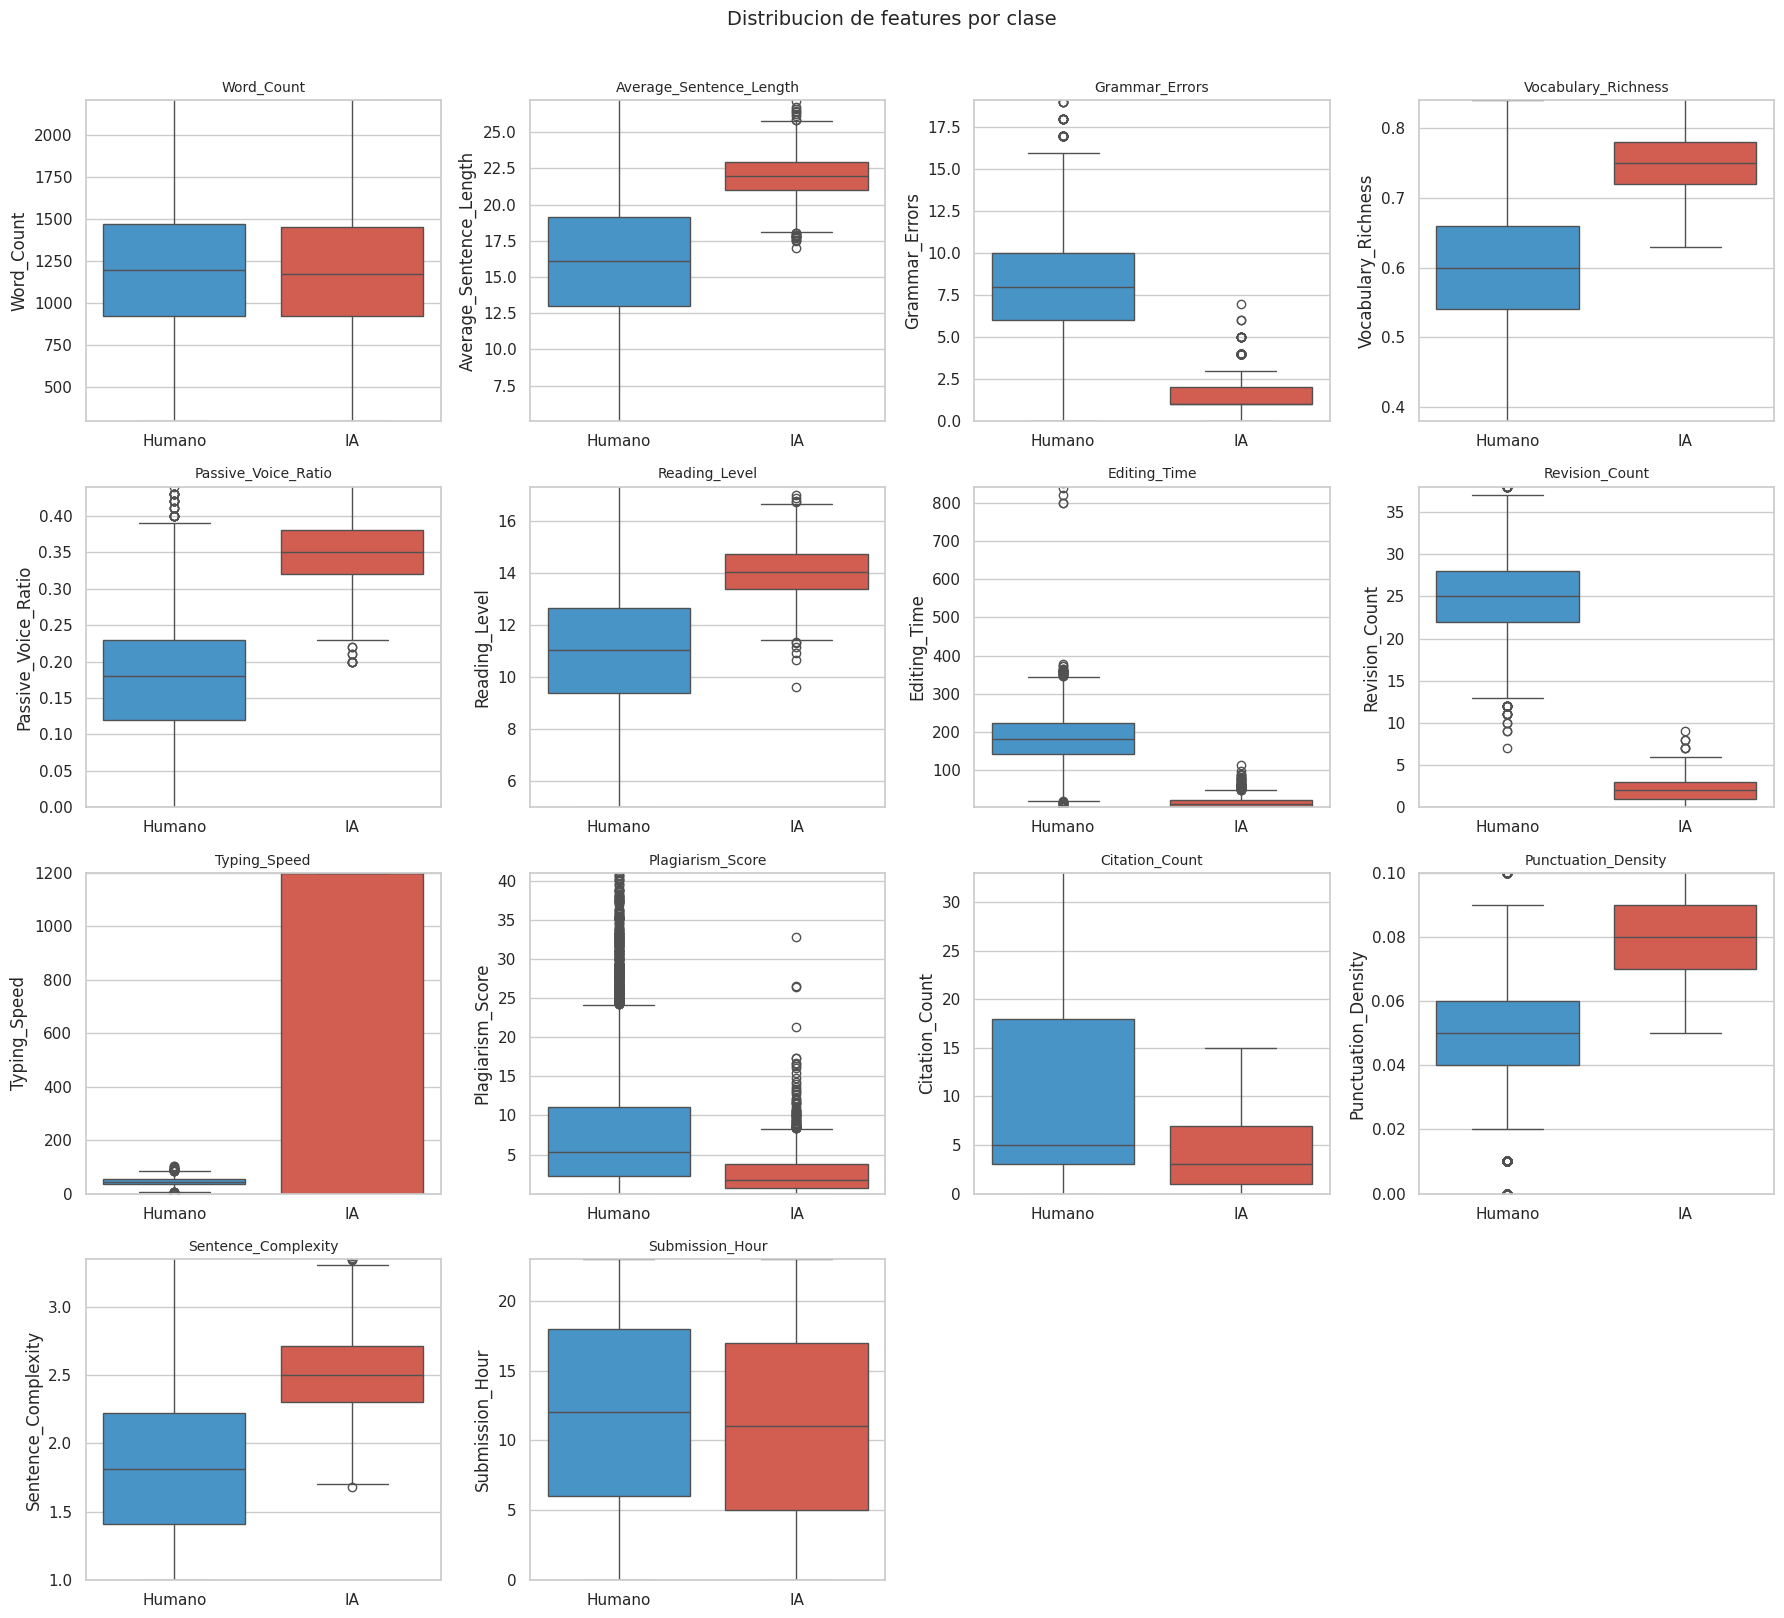

In [7]:
# 3.2  Distribucion de features numericas por clase (boxplots, eje recortado a p0.5-p99.5)
nr = int(np.ceil(len(nums) / 4))
fig, axes = plt.subplots(nr, 4, figsize=(18, 4 * nr))
axes = axes.flatten()

for i, col in enumerate(nums):
    sns.boxplot(data=df, x=tgt, y=col, ax=axes[i],
                palette=['#3498db', '#e74c3c'], hue=tgt, legend=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Humano', 'IA'])
    axes[i].set_ylim(df[col].quantile(0.005), df[col].quantile(0.995))

for j in range(len(nums), len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Distribucion de features por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

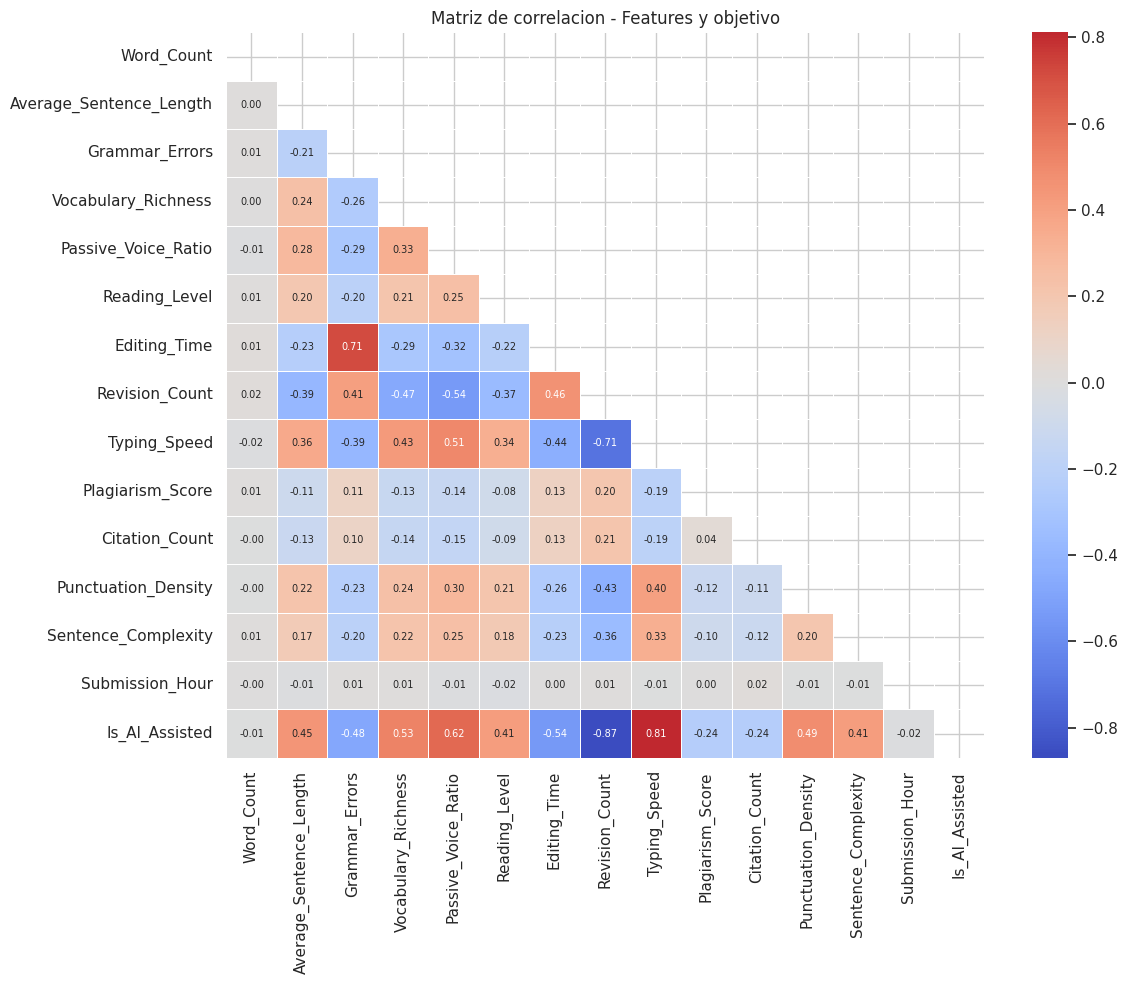

In [8]:
# 3.3  Correlacion entre features numericas y el objetivo
plt.figure(figsize=(12, 10))
corr = df[list(nums) + [tgt]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Matriz de correlacion - Features y objetivo')
plt.tight_layout()
plt.show()

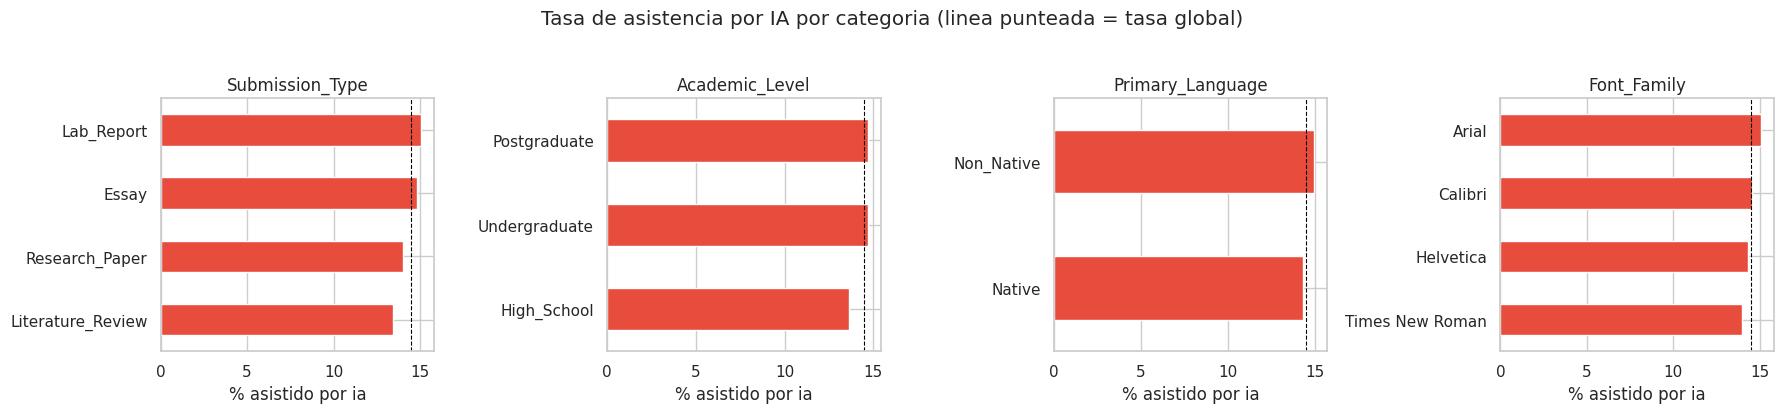

In [9]:
# 3.4  Tasa de asistencia por ia segun variables categoricas
fig, axes = plt.subplots(1, len(cats), figsize=(18, 4))

for ax, col in zip(axes, cats):
    tasa = df.groupby(col)[tgt].mean().sort_values() * 100
    tasa.plot(kind='barh', ax=ax, color='#e74c3c')
    ax.axvline(df[tgt].mean() * 100, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(col)
    ax.set_xlabel('% asistido por ia')
    ax.set_ylabel('')

fig.suptitle('Tasa de asistencia por IA por categoria (linea punteada = tasa global)', y=1.03)
plt.tight_layout()
plt.show()

### Hallazgos del análisis exploratorio
- **La telemetría separa las clases casi por sí sola.** Mediana de revisiones: 2 (IA) vs 25 (humano); tiempo de edición: ~10 vs ~181; y la velocidad de tipeo en la clase IA solo toma dos valores extremos (28% son 0 y 72% son exactamente 1200, un aparente tope), mientras que en humanos casi nunca supera ~100.
- **Las métricas lingüísticas también difieren:** las entregas IA tienen menos errores gramaticales (mediana 1 vs 8), mayor riqueza de vocabulario (0.75 vs 0.60), más voz pasiva (0.35 vs 0.18) y oraciones más largas (22 vs 16 palabras).
- **Variables sin señal:** `Word_Count` y `Submission_Hour` casi no se correlacionan con el objetivo (≈ -0.01 y -0.02), y la tasa de IA es 13–15% en todas las categorías de tipo de entrega, nivel académico, idioma y fuente.
- **Los nulos no delatan la clase:** la proporción de faltantes por columna es similar en ambas clases (8–15%), así que imputar con la mediana es razonable.

---
## 4. Preparación de datos

In [6]:
# 4.1  Separacion features / target (Student_ID es solo un identificador)
X = df.drop(columns=['Student_ID', tgt])
y = df[tgt].copy()

# 4.2  Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=rs, stratify=y
)

print(f'train: {X_train.shape[0]} muestras  |  test: {X_test.shape[0]} muestras')
print(f'proporcion clase 1 en train: {y_train.mean():.3f}')
print(f'proporcion clase 1 en test:  {y_test.mean():.3f}')

train: 8000 muestras  |  test: 2000 muestras
proporcion clase 1 en train: 0.145
proporcion clase 1 en test:  0.145


In [11]:
# 4.3  Verificacion de escalas (justifica la estandarizacion)
print('rangos de las features numericas (train):')
print('=' * 60)
for col in nums:
    mn, mx = X_train[col].min(), X_train[col].max()
    print(f'{col:26s}  [{mn:8.2f}, {mx:8.2f}]  rango: {mx-mn:.2f}')

nn = X_train.isna().sum()
print(f'\ncolumnas con nulos en train: {list(nn[nn > 0].index)}')
print('\n-> las escalas difieren mucho entre features (Typing_Speed vs Punctuation_Density).')
print('   esto afecta directamente a svm y knn (basados en distancias).')
print('   logistic regression tambien se beneficia de la estandarizacion.')

rangos de las features numericas (train):
Word_Count                  [  300.00,  2517.00]  rango: 2217.00
Average_Sentence_Length     [    5.00,    33.62]  rango: 28.62
Grammar_Errors              [    0.00,    78.00]  rango: 78.00
Vocabulary_Richness         [    0.29,     0.90]  rango: 0.61
Passive_Voice_Ratio         [    0.00,     0.52]  rango: 0.52
Reading_Level               [    5.00,    20.00]  rango: 15.00
Editing_Time                [    1.00,  1493.40]  rango: 1492.40
Revision_Count              [    0.00,    45.00]  rango: 45.00
Typing_Speed                [    0.00,  1200.00]  rango: 1200.00
Plagiarism_Score            [    0.00,    72.33]  rango: 72.33
Citation_Count              [    0.00,    36.00]  rango: 36.00
Punctuation_Density         [    0.00,     0.13]  rango: 0.13
Sentence_Complexity         [    1.00,     4.06]  rango: 3.06
Submission_Hour             [    0.00,    23.00]  rango: 23.00

columnas con nulos en train: ['Editing_Time', 'Revision_Count', 'Typing_S

In [7]:
# 4.4  Preprocesadores: imputacion (mediana) + one-hot; con y sin estandarizacion
num_sc = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])
num_ns = Pipeline([('imp', SimpleImputer(strategy='median'))])

prep_sc = ColumnTransformer([
    ('num', num_sc, list(nums)),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cats)
])
prep_ns = ColumnTransformer([
    ('num', num_ns, list(nums)),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cats)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rs)
print(f'{len(nums)} features numericas + {len(cats)} categoricas (one-hot)')

14 features numericas + 4 categoricas (one-hot)


---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima la probabilidad de pertenencia a una clase mediante la función sigmoide. Ideal como **baseline** por su interpretabilidad y eficiencia.

Como la clase de interés (IA) es minoritaria, la métrica de referencia es el **F1 de la clase 1**, y se usa `class_weight='balanced'`.

In [13]:
# 5.1  Pipeline con imputacion + estandarizacion
pipe_lr = Pipeline([
    ('prep', clone(prep_sc)),
    ('clf', LogisticRegression(max_iter=1000, random_state=rs,
                               class_weight='balanced'))
])

scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='f1')
print(f'Logistic Regression - F1 CV: {scores_lr.mean():.4f} +- {scores_lr.std():.4f}')

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Logistic Regression - F1 CV: 0.9991 +- 0.0011


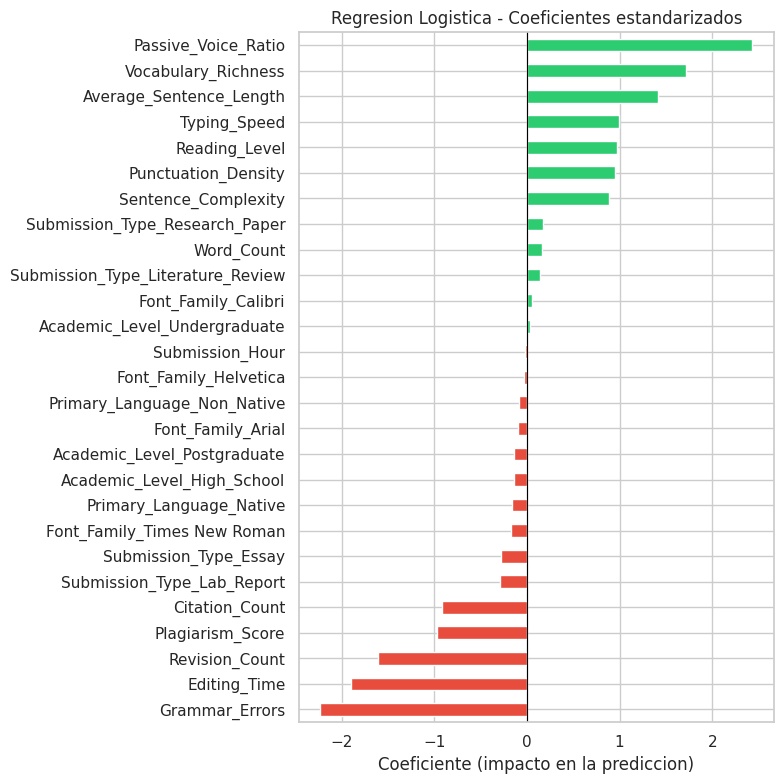


interpretacion: un coeficiente positivo alto indica que valores mayores
de esa feature incrementan la probabilidad de clasificar como "IA".

top 5 por magnitud:
Passive_Voice_Ratio    2.434
Grammar_Errors        -2.232
Editing_Time          -1.906
Vocabulary_Richness    1.714
Revision_Count        -1.609
dtype: float64


In [14]:
# 5.2  Coeficientes del modelo (interpretabilidad)
fn = [n.split('__', 1)[1] for n in pipe_lr.named_steps['prep'].get_feature_names_out()]
coefs = pd.Series(pipe_lr.named_steps['clf'].coef_[0], index=fn).sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs.values]
coefs.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Regresion Logistica - Coeficientes estandarizados')
ax.set_xlabel('Coeficiente (impacto en la prediccion)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\ninterpretacion: un coeficiente positivo alto indica que valores mayores')
print('de esa feature incrementan la probabilidad de clasificar como "IA".')
print('\ntop 5 por magnitud:')
print(coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(5).round(3))

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** Modelo no lineal que particiona el espacio de features mediante reglas if-else jerárquicas. Altamente interpretable, pero propenso al sobreajuste si no se controla la profundidad.

In [15]:
# 6.1  Pipeline (solo imputacion + one-hot, no requiere estandarizacion)
pipe_dt = Pipeline([
    ('prep', clone(prep_ns)),
    ('clf', DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10,
        class_weight='balanced', random_state=rs
    ))
])

scores_dt = cross_val_score(pipe_dt, X_train, y_train, cv=cv, scoring='f1')
print(f'Decision Tree - F1 CV: {scores_dt.mean():.4f} +- {scores_dt.std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Decision Tree - F1 CV: 0.9851 +- 0.0062


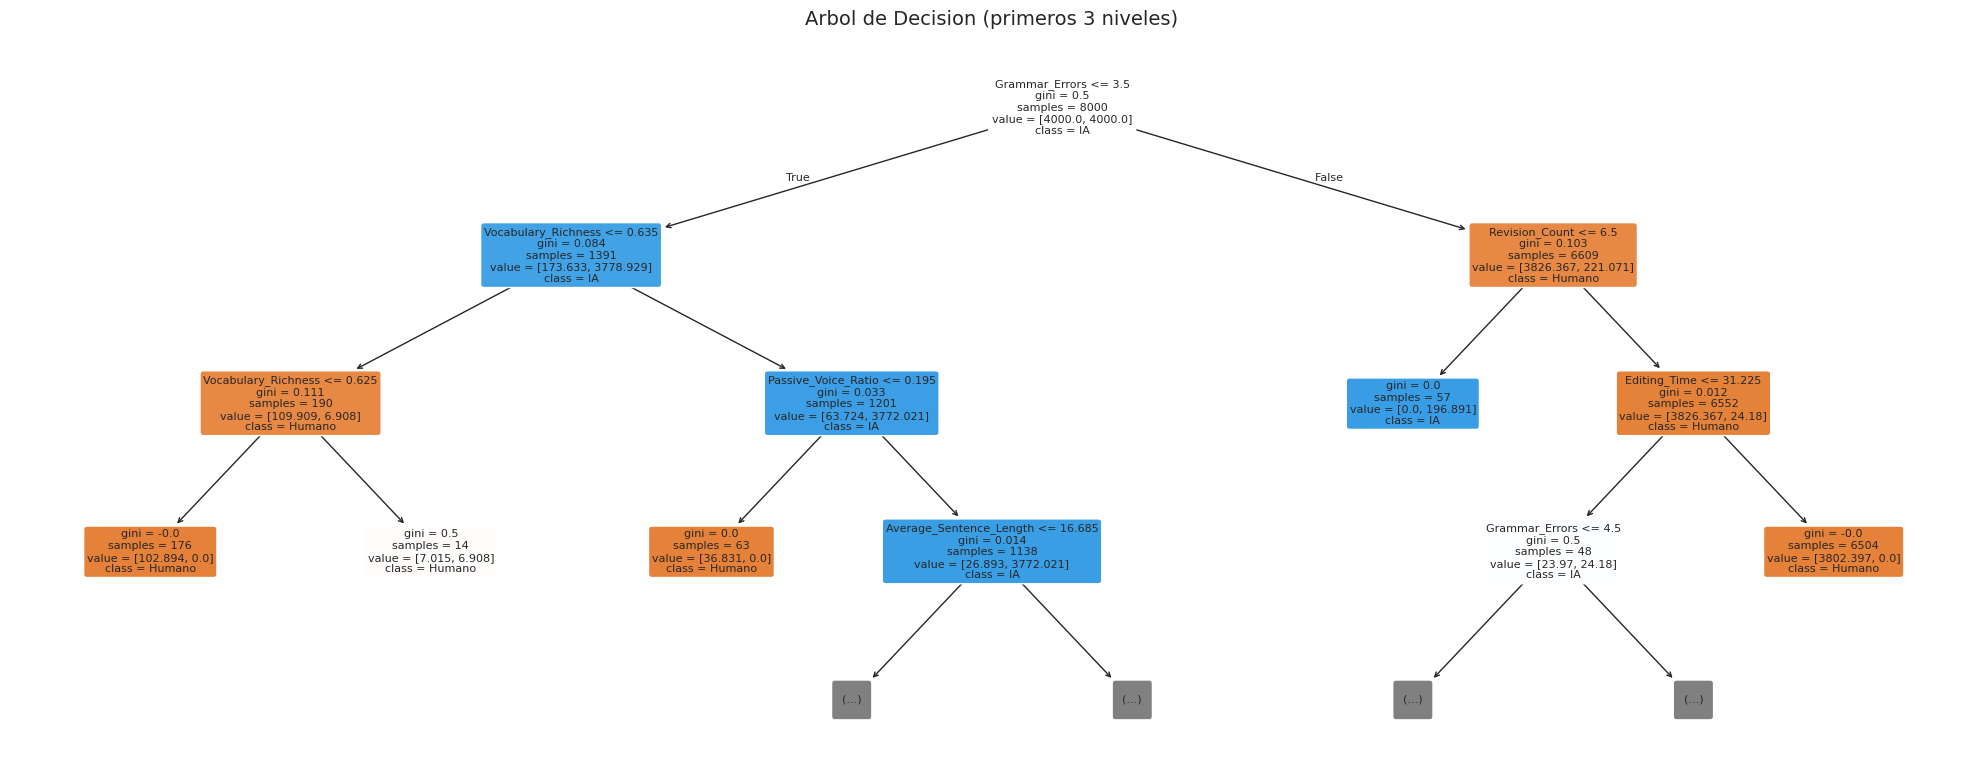

In [16]:
# 6.2  Visualizacion del arbol
fn_dt = [n.split('__', 1)[1] for n in pipe_dt.named_steps['prep'].get_feature_names_out()]

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    pipe_dt.named_steps['clf'],
    feature_names=fn_dt,
    class_names=['Humano', 'IA'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    max_depth=3
)
ax.set_title('Arbol de Decision (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

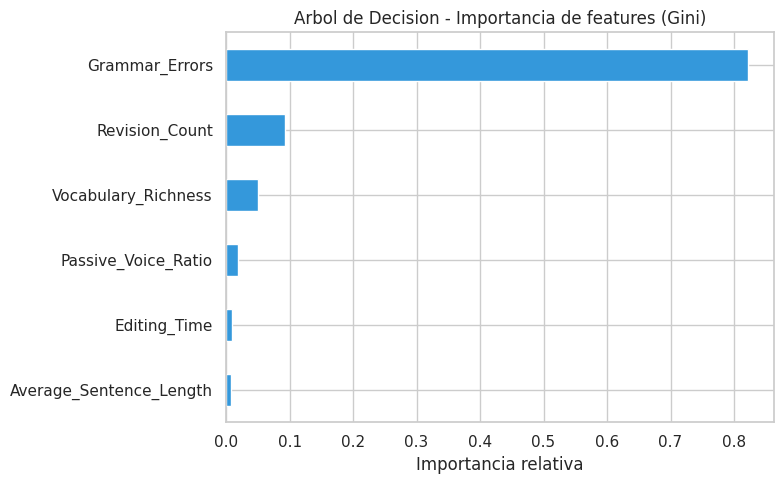

In [17]:
# 6.3  Importancia de features (Gini importance)
imp = pd.Series(pipe_dt.named_steps['clf'].feature_importances_, index=fn_dt)
imp = imp[imp > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
imp.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Arbol de Decision - Importancia de features (Gini)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

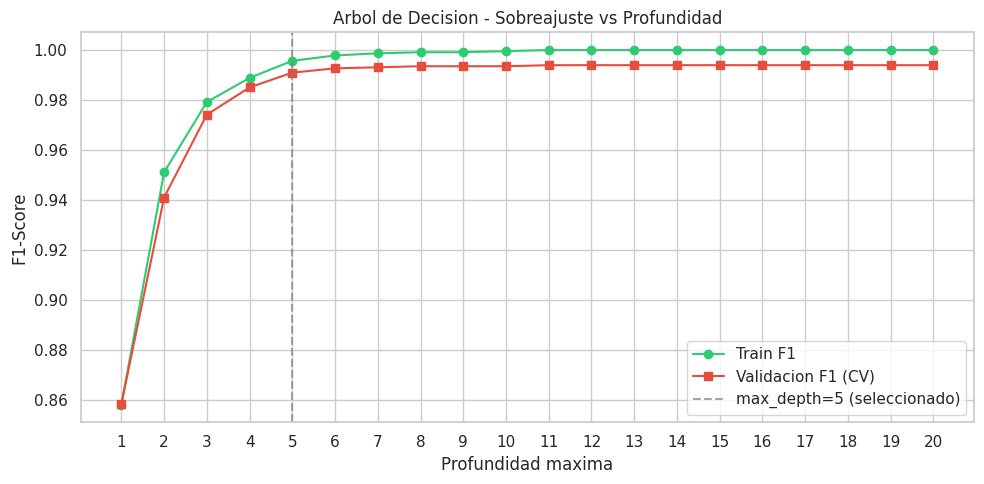

observacion: cuando la brecha entre train y validacion crece,
el modelo esta sobreajustando (memorizando el train set).
mejor profundidad segun validacion: 11 (F1 = 0.9940)


In [18]:
# 6.4  Efecto de la profundidad en sobreajuste/subajuste
depths = range(1, 21)
tr_sc = []
va_sc = []

for d in depths:
    dt = Pipeline([
        ('prep', clone(prep_ns)),
        ('clf', DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                       random_state=rs))
    ])
    dt.fit(X_train, y_train)
    tr_sc.append(f1_score(y_train, dt.predict(X_train)))
    va_sc.append(cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1').mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, tr_sc, 'o-', label='Train F1', color='#2ecc71')
ax.plot(depths, va_sc, 's-', label='Validacion F1 (CV)', color='#e74c3c')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='max_depth=5 (seleccionado)')
ax.set_xlabel('Profundidad maxima')
ax.set_ylabel('F1-Score')
ax.set_title('Arbol de Decision - Sobreajuste vs Profundidad')
ax.legend()
ax.set_xticks(depths)
plt.tight_layout()
plt.show()

print('observacion: cuando la brecha entre train y validacion crece,')
print('el modelo esta sobreajustando (memorizando el train set).')
print(f'mejor profundidad segun validacion: {list(depths)[int(np.argmax(va_sc))]} (F1 = {max(va_sc):.4f})')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** Busca el hiperplano que maximiza el margen de separación entre clases. Con funciones kernel puede manejar fronteras no lineales. Es **sensible a la escala** de las features.

In [19]:
# 7.1  Comparacion de kernels
kernels = ['linear', 'rbf', 'poly']
svm_res = {}

for k in kernels:
    ps = Pipeline([
        ('prep', clone(prep_sc)),
        ('clf', SVC(kernel=k, class_weight='balanced',
                    random_state=rs, probability=True))
    ])
    sc = cross_val_score(ps, X_train, y_train, cv=cv, scoring='f1')
    svm_res[k] = sc
    print(f'SVM ({k:6s}) - F1 CV: {sc.mean():.4f} +- {sc.std():.4f}')

best_kernel = max(svm_res, key=lambda k: svm_res[k].mean())
print(f'\nmejor kernel: {best_kernel}')

SVM (linear) - F1 CV: 0.9983 +- 0.0025


SVM (rbf   ) - F1 CV: 0.9996 +- 0.0009


SVM (poly  ) - F1 CV: 1.0000 +- 0.0000

mejor kernel: poly


In [20]:
# 7.2  Entrenamiento con el mejor kernel
pipe_svm = Pipeline([
    ('prep', clone(prep_sc)),
    ('clf', SVC(kernel=best_kernel, class_weight='balanced',
                random_state=rs, probability=True))
])

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)
scores_svm = svm_res[best_kernel]

In [21]:
# 7.3  Impacto de la estandarizacion en SVM (misma imputacion y one-hot, sin StandardScaler)
svm_ns = Pipeline([
    ('prep', clone(prep_ns)),
    ('clf', SVC(kernel=best_kernel, class_weight='balanced', random_state=rs))
])
scores_ns = cross_val_score(svm_ns, X_train, y_train, cv=cv, scoring='f1')

print('impacto de la estandarizacion en svm:')
print(f'  CON StandardScaler: F1 = {scores_svm.mean():.4f}')
print(f'  SIN StandardScaler: F1 = {scores_ns.mean():.4f}')
print(f'  diferencia: {(scores_svm.mean() - scores_ns.mean())*100:+.2f} puntos porcentuales')
print('\n-> la estandarizacion es CRITICA para modelos basados en distancias.')

impacto de la estandarizacion en svm:
  CON StandardScaler: F1 = 1.0000
  SIN StandardScaler: F1 = 0.9320
  diferencia: +6.80 puntos porcentuales

-> la estandarizacion es CRITICA para modelos basados en distancias.


---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Clasifica según la mayoría de votos de los K vecinos más cercanos. No paramétrico, sensible a la escala y a la dimensionalidad. El valor de K controla el trade-off bias-varianza.

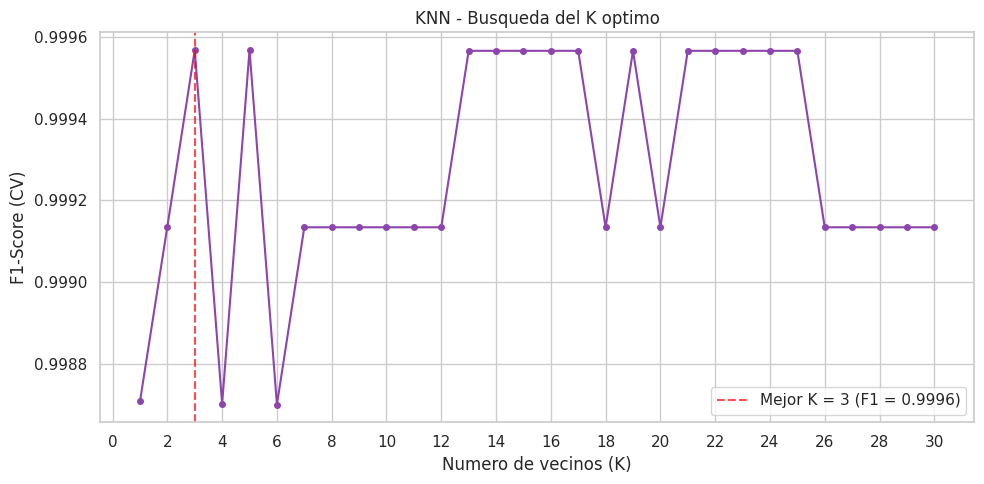

k optimo: 3


In [22]:
# 8.1  Busqueda del K optimo
k_range = range(1, 31)
k_scores = []

for k in k_range:
    pk = Pipeline([
        ('prep', clone(prep_sc)),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    sc = cross_val_score(pk, X_train, y_train, cv=cv, scoring='f1')
    k_scores.append(sc.mean())

best_k = k_range[np.argmax(k_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_scores, 'o-', markersize=4, color='#8e44ad')
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
           label=f'Mejor K = {best_k} (F1 = {max(k_scores):.4f})')
ax.set_xlabel('Numero de vecinos (K)')
ax.set_ylabel('F1-Score (CV)')
ax.set_title('KNN - Busqueda del K optimo')
ax.legend()
ax.set_xticks(range(0, 31, 2))
plt.tight_layout()
plt.show()

print(f'k optimo: {best_k}')

In [23]:
# 8.2  Entrenamiento con K optimo
pipe_knn = Pipeline([
    ('prep', clone(prep_sc)),
    ('clf', KNeighborsClassifier(n_neighbors=best_k))
])

scores_knn = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
print(f'KNN (K={best_k}) - F1 CV: {scores_knn.mean():.4f} +- {scores_knn.std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=3) - F1 CV: 0.9996 +- 0.0009


---
## 9. Análisis comparativo de modelos

In [24]:
# 9.1  Tabla resumen
models = {
    'Logistic Regression': (pipe_lr, y_pred_lr, scores_lr),
    'Decision Tree':       (pipe_dt, y_pred_dt, scores_dt),
    f'SVM ({best_kernel})': (pipe_svm, y_pred_svm, scores_svm),
    f'KNN (K={best_k})':   (pipe_knn, y_pred_knn, scores_knn)
}

resumen = []
for name, (pipe, y_pred, cv_sc) in models.items():
    if hasattr(pipe, 'predict_proba'):
        pr = pipe.predict_proba(X_test)[:, 1]
    else:
        pr = pipe.decision_function(X_test)
    resumen.append({
        'Modelo': name,
        'F1 CV (mean)': f'{cv_sc.mean():.4f}',
        'F1 CV (std)': f'{cv_sc.std():.4f}',
        'Accuracy Test': f'{accuracy_score(y_test, y_pred):.4f}',
        'F1 Test': f'{f1_score(y_test, y_pred):.4f}',
        'ROC AUC Test': f'{roc_auc_score(y_test, pr):.4f}'
    })

resumen_df = pd.DataFrame(resumen)
print('=' * 80)
print('COMPARACION DE MODELOS')
print('=' * 80)
resumen_df

COMPARACION DE MODELOS


,Modelo,F1 CV (mean),F1 CV (std),Accuracy Test,F1 Test,ROC AUC Test
0,Logistic Regression,0.9991,0.0011,0.9995,0.9983,1.0000
1,Decision Tree,0.9851,0.0062,0.9970,0.9897,0.9974
2,SVM (poly),1.0000,0.0000,0.9995,0.9983,1.0000
3,KNN (K=3),0.9996,0.0009,1.0000,1.0000,1.0000


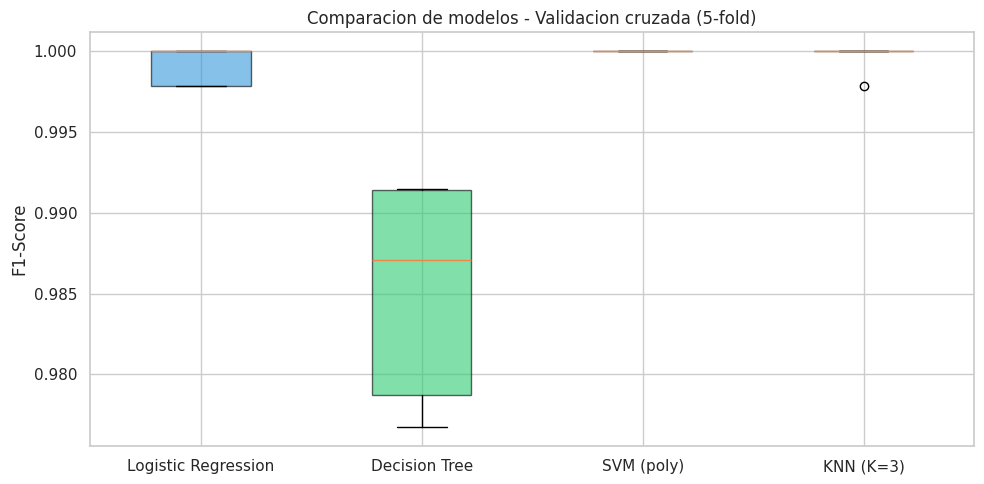

In [25]:
# 9.2  Boxplot comparativo de validacion cruzada
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = [scores_lr, scores_dt, scores_svm, scores_knn]
labels = list(models.keys())
bp = ax.boxplot(cv_data, tick_labels=labels, patch_artist=True)
colors_box = ['#3498db', '#2ecc71', '#e74c3c', '#8e44ad']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('F1-Score')
ax.set_title('Comparacion de modelos - Validacion cruzada (5-fold)')
plt.tight_layout()
plt.show()

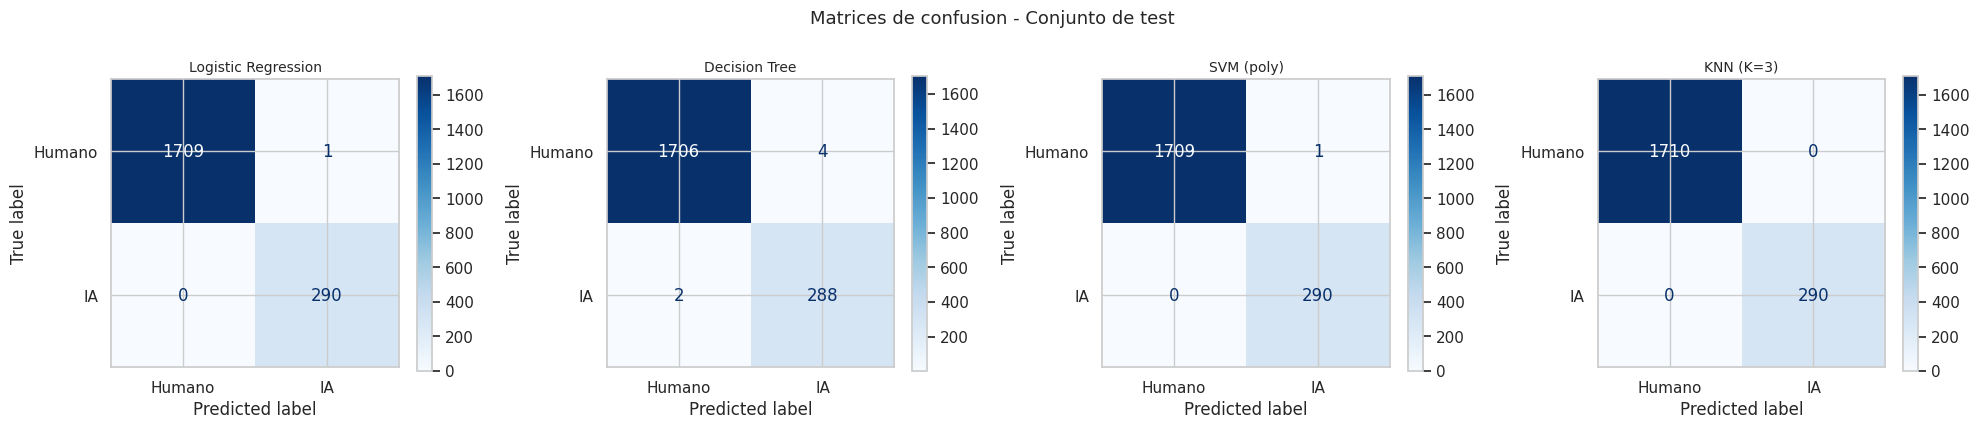

In [26]:
# 9.3  Matrices de confusion comparativas
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, (pipe, y_pred, _)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Humano', 'IA'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=10)

fig.suptitle('Matrices de confusion - Conjunto de test', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

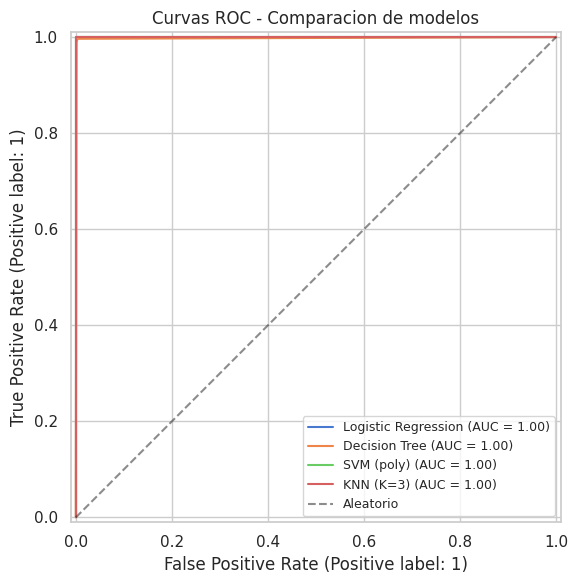

In [27]:
# 9.4  Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(7, 6))

for name, (pipe, _, _) in models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_title('Curvas ROC - Comparacion de modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [28]:
# 9.5  Classification report detallado del mejor modelo
best_name = max(models, key=lambda k: float(models[k][2].mean()))
best_pipe, best_pred, best_cv = models[best_name]

print(f'\nmejor modelo: {best_name}')
print('=' * 60)
print(classification_report(y_test, best_pred, target_names=['Humano', 'IA']))


mejor modelo: SVM (poly)
              precision    recall  f1-score   support

      Humano       1.00      1.00      1.00      1710
          IA       1.00      1.00      1.00       290

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



### Lectura de resultados
- **El problema es casi perfectamente separable.** Los cuatro modelos superan F1 = 0.98 en validación cruzada y ROC AUC ≥ 0.997 en test. Es coherente con el EDA: las variables de telemetría (sobre todo el tipeo con valores extremos, revisiones y tiempo de edición) dejan poco espacio para el error. Además, el dataset es **sintético**, por lo que estos resultados no deben extrapolarse a detección de IA en textos reales.
- **Regresión Logística, SVM y KNN están en el techo** (F1 CV: 0.9991, 1.0000 y 0.9996). En test cometen 1, 1 y 0 errores sobre 2000 muestras, diferencias que no bastan para declarar un ganador claro.
- **El Árbol de Decisión es el más débil** (F1 CV 0.9851 ± 0.0062; 6 errores en test; AUC 0.9974). Con `max_depth=5` subajusta un poco: en la curva de la sección 6.4 la validación mejora hasta profundidad 11 (F1 0.9940).
- **La estandarización importa:** el SVM sin `StandardScaler` baja de 1.0000 a 0.9320 (-6.8 puntos), por las escalas tan distintas entre `Typing_Speed` (0–1200) y `Punctuation_Density` (0–0.13).
- **Interpretabilidad:** los coeficientes con mayor magnitud en la regresión logística son `Passive_Voice_Ratio` (+2.43), `Grammar_Errors` (-2.23), `Editing_Time` (-1.91), `Vocabulary_Richness` (+1.71) y `Revision_Count` (-1.61); hay mucha información redundante entre variables, por lo que conviene leerlos con cautela.

---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Regresión Logística** | Rápido, interpretable (coeficientes), probabilístico | Asume relación lineal entre features y log-odds | Baseline; cuando la interpretabilidad es prioritaria |
| **Árbol de Decisión** | Interpretable (visualización), maneja no linealidades, no requiere estandarización | Propenso a sobreajuste; inestable (pequeños cambios en datos alteran el árbol) | Cuando se necesitan reglas explicables; como parte de ensambles |
| **SVM** | Efectivo en alta dimensionalidad; flexible con kernels | Sensible a la escala; costoso en datasets grandes; difícil de interpretar | Datasets de tamaño moderado con fronteras complejas |
| **KNN** | Simple, no paramétrico, adaptable | Lento en predicción (distancias contra todo el train); sensible a escala y dimensionalidad | Datasets pequeños-medianos; cuando la frontera es irregular |

**Para este dataset:** la Regresión Logística ya alcanza prácticamente el máximo con un modelo simple e interpretable, por lo que es un baseline difícil de superar; SVM y KNN igualan su rendimiento a costa de mayor complejidad y, en el caso de KNN, de una predicción más lenta.

---
## 11. Ejercicios propuestos — Tarea de la sesión 02 (Clasificación I)

La sección 11 corresponde a la tarea de la sesión **`sesion_02_modelos_clasificacion_I`**. Se conserva aquí con sus ejercicios adaptados al dataset AI vs Human y las resoluciones ya desarrolladas.

### Ejercicio 1 — GridSearchCV para SVM
Realice una búsqueda de hiperparámetros para SVM usando `GridSearchCV` con la siguiente grilla:
- `C`: [0.1, 1, 10, 100]
- `gamma`: ['scale', 'auto', 0.01, 0.1]
- `kernel`: ['rbf', 'poly']

Reporte los mejores hiperparámetros, el F1-score obtenido y compare contra el SVM base de la sesión.

### Ejercicio 2 — Clasificación multiclase
En lugar de binarizar la variable `quality`, utilice las clases originales (3–8) y entrene los 4 modelos. Analice:
- ¿Cómo cambia el rendimiento de cada modelo?
- ¿Qué clases son más difíciles de distinguir?
- ¿Qué métrica de F1 es más adecuada: `macro`, `micro` o `weighted`? Justifique.

> **Adaptación al nuevo dataset:** `Is_AI_Assisted` ya es binaria y no existe una variable "original" con varias clases como `quality`. Para el ejercicio 2 se usa **`Submission_Type`** (Essay, Lab_Report, Literature_Review, Research_Paper) como variable multiclase, con las mismas features que antes (sin `Submission_Type` como entrada).

### Ejercicio 3 — Aplicación con dataset propio
Seleccione un dataset de clasificación de su interés (puede ser de Kaggle, UCI, o datos propios). Debe tener al menos 500 registros y 5 features. Aplique los 4 modelos de clasificación, realice el análisis comparativo completo y documente sus hallazgos.

---
### Resolución del Ejercicio 1 — GridSearchCV para SVM

In [29]:
# e1.1  Grilla y busqueda (pipeline completo: la imputacion y la escala se ajustan dentro de cada fold)
pipe_gs = Pipeline([
    ('prep', clone(prep_sc)),
    ('clf', SVC(class_weight='balanced', random_state=rs))
])

grid = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 'auto', 0.01, 0.1],
    'clf__kernel': ['rbf', 'poly']
}

gs = GridSearchCV(pipe_gs, grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)

print('\nmejores hiperparametros:')
for k, v in gs.best_params_.items():
    print(f'  {k.split("__")[1]:7s}: {v}')
print(f'\nmejor F1 CV: {gs.best_score_:.4f}')

Fitting 5 folds for each of 32 candidates, totalling 160 fits



mejores hiperparametros:
  C      : 0.1
  gamma  : 0.1
  kernel : poly

mejor F1 CV: 1.0000


In [30]:
# e1.2  Top 5 combinaciones
rs_gs = pd.DataFrame(gs.cv_results_)
top = rs_gs.sort_values('rank_test_score').head(5)[
    ['param_clf__kernel', 'param_clf__C', 'param_clf__gamma', 'mean_test_score', 'std_test_score']
]
top.columns = ['kernel', 'C', 'gamma', 'F1 CV (mean)', 'F1 CV (std)']
print(top.round(4).reset_index(drop=True).to_string())

mx = rs_gs['mean_test_score'].max()
print(f'\ncombinaciones que empatan en el maximo ({mx:.4f}): {(rs_gs["mean_test_score"] >= mx - 1e-9).sum()} de {len(rs_gs)}')
print('\nestabilidad por kernel (F1 CV sobre las 16 combinaciones de cada uno):')
print(rs_gs.groupby('param_clf__kernel')['mean_test_score'].agg(['min', 'mean', 'max']).round(4))

  kernel      C  gamma  F1 CV (mean)  F1 CV (std)
0   poly    0.1    0.1           1.0          0.0
1   poly    1.0  scale           1.0          0.0
2   poly    1.0    0.1           1.0          0.0
3   poly  100.0   0.01           1.0          0.0
4   poly  100.0  scale           1.0          0.0

combinaciones que empatan en el maximo (1.0000): 10 de 32

estabilidad por kernel (F1 CV sobre las 16 combinaciones de cada uno):
                      min    mean     max
param_clf__kernel                        
poly               0.8892  0.9922  1.0000
rbf                0.9983  0.9994  0.9996


In [31]:
# e1.3  Comparacion contra el svm base de la sesion (CV y test)
y_pred_gs = gs.best_estimator_.predict(X_test)

comp_gs = pd.DataFrame({
    'Modelo': [f'SVM base ({best_kernel}, C=1, gamma=scale)', 'SVM GridSearchCV'],
    'F1 CV': [scores_svm.mean(), gs.best_score_],
    'F1 Test': [f1_score(y_test, y_pred_svm), f1_score(y_test, y_pred_gs)],
    'Accuracy Test': [accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_gs)]
}).round(4)
print(comp_gs.to_string(index=False))
print(f'\nmejora en F1 CV:   {(gs.best_score_ - scores_svm.mean())*100:+.2f} puntos porcentuales')
print(f'mejora en F1 Test: {(f1_score(y_test, y_pred_gs) - f1_score(y_test, y_pred_svm))*100:+.2f} puntos porcentuales')

                           Modelo  F1 CV  F1 Test  Accuracy Test
SVM base (poly, C=1, gamma=scale)    1.0   0.9983         0.9995
                 SVM GridSearchCV    1.0   0.9983         0.9995

mejora en F1 CV:   +0.00 puntos porcentuales
mejora en F1 Test: +0.00 puntos porcentuales


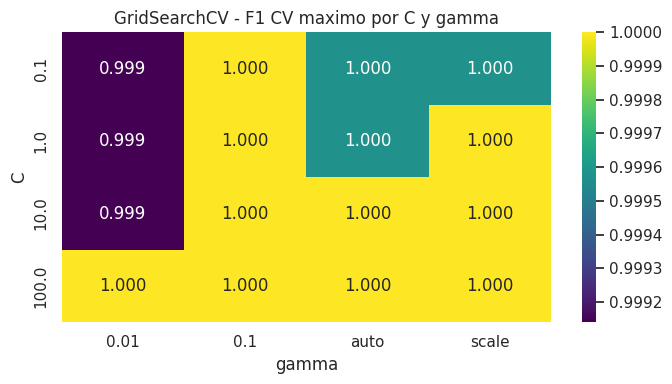

In [32]:
# e1.4  Mapa de calor: F1 CV por C y gamma (mejor kernel de cada celda)
pv = rs_gs.pivot_table(index='param_clf__C', columns='param_clf__gamma',
                       values='mean_test_score', aggfunc='max').astype(float)

plt.figure(figsize=(7, 4))
sns.heatmap(pv, annot=True, fmt='.3f', cmap='viridis')
plt.title('GridSearchCV - F1 CV maximo por C y gamma')
plt.xlabel('gamma')
plt.ylabel('C')
plt.tight_layout()
plt.show()

### Respuesta — Ejercicio 1
- **Mejores hiperparámetros:** `kernel='poly'`, `C=0.1`, `gamma=0.1`, con **F1 CV = 1.0000**.
- **Comparación con el SVM base** (`poly`, `C=1`, `gamma='scale'`): F1 CV 1.0000 en ambos y F1 en test 0.9983 en ambos (1 error sobre 2000 muestras). La mejora es de **0.00 puntos porcentuales**.
- **Por qué no mejora:** 10 de las 32 combinaciones empatan en F1 CV = 1.0000 y `GridSearchCV` devuelve la primera del empate, por lo que `C=0.1, gamma=0.1` no tiene nada especial. El SVM base ya estaba en el techo; no hay margen que la búsqueda pueda aprovechar.
- **Lo que sí muestra la grilla es la estabilidad:** el kernel `rbf` rinde entre 0.9983 y 0.9996 en las 16 combinaciones (robusto), mientras que `poly` llega más alto (1.0000) pero se mueve entre 0.8892 y 1.0000 según `C` y `gamma`. Si hubiera que elegir un modelo para usar en la práctica, `rbf` es la opción más segura.

---
### Resolución del Ejercicio 2 — Clasificación multiclase (`Submission_Type`)

In [33]:
# e2.1  Nueva variable objetivo y split estratificado
tgt2 = 'Submission_Type'
cats2 = [c for c in cats if c != tgt2]

X2 = df[list(nums) + cats2].copy()
y2 = df[tgt2].copy()
cls2 = sorted(y2.unique())

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.20, random_state=rs, stratify=y2
)

print(y2.value_counts().to_string())
print(f'\nclases: {cls2}')

prep2_sc = ColumnTransformer([
    ('num', num_sc, list(nums)),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cats2)
])
prep2_ns = ColumnTransformer([
    ('num', num_ns, list(nums)),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cats2)
])

Submission_Type
Essay                3926
Research_Paper       3002
Lab_Report           2051
Literature_Review    1021

clases: ['Essay', 'Lab_Report', 'Literature_Review', 'Research_Paper']


In [34]:
# e2.2  Entrenamiento de los 4 modelos (mismos hiperparametros que en el caso binario)
mods2 = {
    'Logistic Regression': Pipeline([
        ('prep', clone(prep2_sc)),
        ('clf', LogisticRegression(max_iter=1000, random_state=rs, class_weight='balanced'))]),
    'Decision Tree': Pipeline([
        ('prep', clone(prep2_ns)),
        ('clf', DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                       class_weight='balanced', random_state=rs))]),
    f'SVM ({best_kernel})': Pipeline([
        ('prep', clone(prep2_sc)),
        ('clf', SVC(kernel=best_kernel, class_weight='balanced', random_state=rs))]),
    f'KNN (K={best_k})': Pipeline([
        ('prep', clone(prep2_sc)),
        ('clf', KNeighborsClassifier(n_neighbors=best_k))])
}

dum = DummyClassifier(strategy='most_frequent').fit(X2_train, y2_train)
yd = dum.predict(X2_test)

fil = [{
    'Modelo': 'Baseline (clase mayoritaria)',
    'F1 macro CV': np.nan,
    'Accuracy': accuracy_score(y2_test, yd),
    'F1 micro': f1_score(y2_test, yd, average='micro'),
    'F1 macro': f1_score(y2_test, yd, average='macro'),
    'F1 weighted': f1_score(y2_test, yd, average='weighted')
}]
pred2 = {}

for name, pipe in mods2.items():
    cvs = cross_val_score(pipe, X2_train, y2_train, cv=cv, scoring='f1_macro')
    pipe.fit(X2_train, y2_train)
    yp = pipe.predict(X2_test)
    pred2[name] = yp
    fil.append({
        'Modelo': name,
        'F1 macro CV': cvs.mean(),
        'Accuracy': accuracy_score(y2_test, yp),
        'F1 micro': f1_score(y2_test, yp, average='micro'),
        'F1 macro': f1_score(y2_test, yp, average='macro'),
        'F1 weighted': f1_score(y2_test, yp, average='weighted')
    })

res2 = pd.DataFrame(fil).round(4)
res2

,Modelo,F1 macro CV,Accuracy,F1 micro,F1 macro,F1 weighted
0,Baseline (clase mayoritaria),NaN,0.3925,0.3925,0.1409,0.2213
1,Logistic Regression,0.6708,0.6365,0.6365,0.6654,0.6484
2,Decision Tree,0.6806,0.6665,0.6665,0.6809,0.6746
3,SVM (poly),0.6814,0.6460,0.6460,0.6887,0.6621
4,KNN (K=3),0.5901,0.6070,0.6070,0.5891,0.6019


In [35]:
# e2.3  Comparacion binario vs multiclase (F1 macro en test) y ganancia sobre el azar
bin_f1 = {n: f1_score(y_test, v[1]) for n, v in models.items()}
mul_f1 = {n: f1_score(y2_test, p, average='macro') for n, p in pred2.items()}

cmp = pd.DataFrame({
    'F1 binario (clase IA)': bin_f1,
    'F1 macro multiclase': mul_f1
}).round(4)
print(cmp)
print(f'\nazar teorico multiclase (accuracy, {len(cls2)} clases desbalanceadas): {y2_test.value_counts(normalize=True).max():.4f} (clase mayoritaria)')

                     F1 binario (clase IA)  F1 macro multiclase
Logistic Regression                 0.9983               0.6654
Decision Tree                       0.9897               0.6809
SVM (poly)                          0.9983               0.6887
KNN (K=3)                           1.0000               0.5891

azar teorico multiclase (accuracy, 4 clases desbalanceadas): 0.3925 (clase mayoritaria)


                     Essay  Lab_Report  Literature_Review  Research_Paper
Logistic Regression  0.570       0.369              0.849           0.874
Decision Tree        0.655       0.284              0.892           0.893
SVM (poly)           0.551       0.391              0.902           0.911
KNN (K=3)            0.630       0.257              0.703           0.767

soporte en test:
Submission_Type
Essay                785
Lab_Report           410
Literature_Review    204
Research_Paper       601


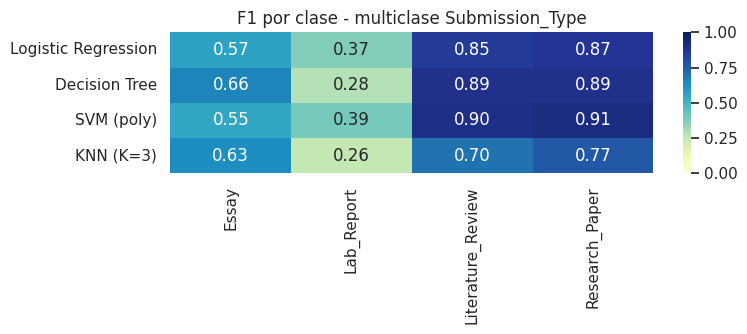

In [36]:
# e2.4  F1 por clase (que clases son mas dificiles)
pc = pd.DataFrame({
    n: f1_score(y2_test, p, labels=cls2, average=None) for n, p in pred2.items()
}, index=cls2).T.round(3)
pc['Soporte (test)'] = ''
print(pc.drop(columns='Soporte (test)'))
print('\nsoporte en test:')
print(y2_test.value_counts().reindex(cls2).to_string())

plt.figure(figsize=(8, 3.5))
sns.heatmap(pc.drop(columns='Soporte (test)').astype(float), annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1)
plt.title('F1 por clase - multiclase Submission_Type')
plt.tight_layout()
plt.show()

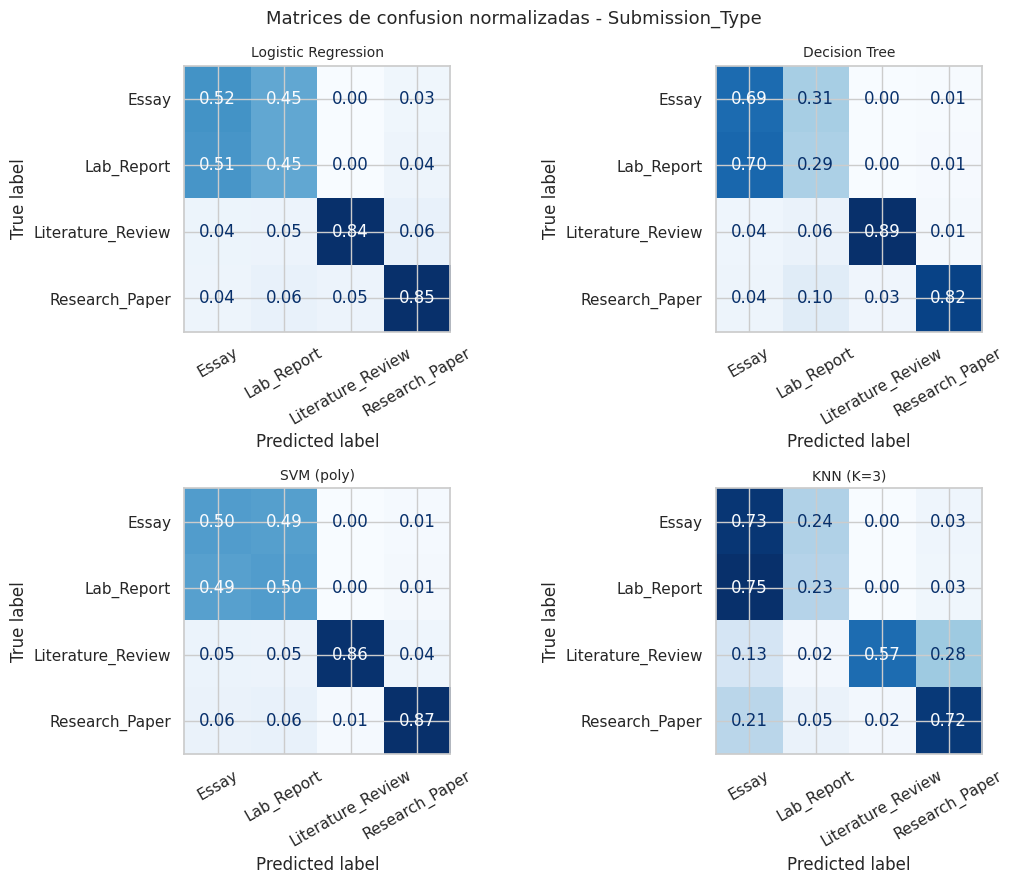

In [37]:
# e2.5  Matrices de confusion normalizadas por fila (recall por clase)
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for ax, (name, yp) in zip(axes.flatten(), pred2.items()):
    ConfusionMatrixDisplay.from_predictions(
        y2_test, yp, labels=cls2, normalize='true',
        cmap='Blues', ax=ax, xticks_rotation=30, values_format='.2f', colorbar=False
    )
    ax.set_title(name, fontsize=10)

fig.suptitle('Matrices de confusion normalizadas - Submission_Type', fontsize=13)
plt.tight_layout()
plt.show()

                     Accuracy  F1 micro  F1 macro  F1 weighted
Modelo                                                        
Logistic Regression    0.6365    0.6365    0.6654       0.6484
Decision Tree          0.6665    0.6665    0.6809       0.6746
SVM (poly)             0.6460    0.6460    0.6887       0.6621
KNN (K=3)              0.6070    0.6070    0.5891       0.6019

F1 micro == accuracy en todos los modelos: True


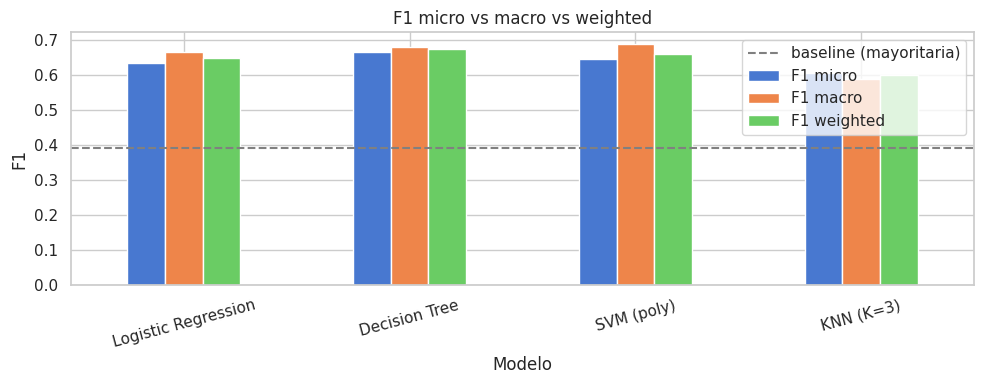

In [38]:
# e2.6  Las tres variantes de F1 frente a la prevalencia de clases
ex = res2[res2['Modelo'] != 'Baseline (clase mayoritaria)'].set_index('Modelo')[['Accuracy', 'F1 micro', 'F1 macro', 'F1 weighted']]
print(ex)
print(f'\nF1 micro == accuracy en todos los modelos: {bool(np.allclose(ex["Accuracy"], ex["F1 micro"]))}')

ex[['F1 micro', 'F1 macro', 'F1 weighted']].plot(kind='bar', figsize=(10, 4), rot=15)
plt.axhline(y2_test.value_counts(normalize=True).max(), color='gray', linestyle='--', label='baseline (mayoritaria)')
plt.ylabel('F1')
plt.title('F1 micro vs macro vs weighted')
plt.legend()
plt.tight_layout()
plt.show()

### Respuesta — Ejercicio 2
**¿Cómo cambia el rendimiento?** Cae de forma marcada: el F1 del caso binario (0.99–1.00) pasa a un **F1 macro de 0.59–0.69** en la clasificación de 4 tipos de entrega. SVM (poly) obtiene el mejor F1 macro en test (0.6887), seguido de Árbol de Decisión (0.6809), Regresión Logística (0.6654) y KNN (0.5891). Todos superan el baseline de la clase mayoritaria (accuracy 0.3925), pero por un margen moderado. KNN es el más afectado; hay que recordar que se usó K=3, elegido para el problema binario, y que los hiperparámetros no se volvieron a ajustar para el caso multiclase.

**¿Qué clases son más difíciles de distinguir?** **`Essay` y `Lab_Report`**, que se confunden entre sí: el F1 de `Lab_Report` está entre 0.26 y 0.39 y el de `Essay` entre 0.55 y 0.66, mientras que `Literature_Review` y `Research_Paper` alcanzan 0.70–0.91. En las matrices de confusión, la regresión logística asigna 45% de los `Essay` a `Lab_Report` y 51% de los `Lab_Report` a `Essay`, y el SVM reparte ~50/50, es decir, casi al azar entre ambas. La señal más clara para separar tipos es `Citation_Count` (mediana 29 en `Literature_Review`, 17 en `Research_Paper` y 3 tanto en `Essay` como en `Lab_Report`), y entre `Essay` y `Lab_Report` no hay una variable que las distinga. Como `Essay` es más frecuente (39% vs 21%), los modelos tienden a favorecerla y `Lab_Report` sale peor parada.

**¿Qué métrica de F1 es más adecuada?** **`macro`**, por estas razones:
- `micro` es idéntico al accuracy en clasificación multiclase de una sola etiqueta (se verifica en la celda e2.6), así que no aporta información nueva y está dominado por las clases grandes (`Essay` y `Research_Paper` suman ~69% de los datos).
- `weighted` pondera por frecuencia, de modo que el mal desempeño en clases pequeñas como `Lab_Report` o `Literature_Review` queda diluido.
- `macro` da el mismo peso a cada clase y expone justamente esas fallas. La elección cambia el veredicto: por accuracy/micro y weighted gana el Árbol de Decisión (0.6665 y 0.6746), pero por macro gana el SVM (0.6887), porque rinde mejor en las clases minoritarias (F1 de 0.90 en `Literature_Review`).

Lo razonable es reportar `macro` como métrica principal y `weighted` como complemento, junto con el F1 por clase.

---
## 12. Tarea de la sesión 02 — Modelos de Clasificación II

La sección 11 anterior corresponde a la tarea de **Clasificación I**. Esta sección resuelve la tarea pendiente de **`sesion_02_modelos_clasificacion_II`** sobre el dataset AI vs Human Academic Writing (10,200 registros originales, 18 features predictoras y target binario `Is_AI_Assisted`). En los ejercicios 1 y 2, la clase positiva de interés es **IA (1)**, en lugar de la clase maligna del dataset de cáncer.

### Ejercicio 1 — Optimización con GridSearchCV
Buscar hiperparámetros para Regresión Logística, Árbol de Decisión, SVM y KNN mediante `GridSearchCV(cv=5, scoring='f1')`, y comparar los mejores modelos.

### Ejercicio 2 — Desbalance con `class_weight` y SMOTE
Comparar el recall de la clase IA con y sin balanceo. KNN no tiene parámetro `class_weight`; para cubrir los cuatro modelos se compara KNN sin peso y además se aplica SMOTE a todos. El preprocesamiento y el sobremuestreo se ajustan sólo en entrenamiento.

### Ejercicio 3 — Dataset propio
El dataset AI vs Human cumple el mínimo solicitado. Ya se evaluaron los cuatro modelos base; se añade **Random Forest** como quinto algoritmo. Se comparan métricas, curvas ROC, matrices de confusión (matriz de selección) y la elección del mejor modelo.

### Resolución del Ejercicio 1 — Búsqueda exhaustiva de los cuatro modelos

Se conserva el preprocesamiento dentro de cada pipeline para evitar fuga de información. La tabla final compara F1 de validación cruzada y métricas en el conjunto de test.

In [9]:
from sklearn.metrics import recall_score

grid_specs_ii = {
    'Regresión Logística': (
        LogisticRegression(max_iter=2000, random_state=rs),
        {'clf__C': [0.01, 0.1, 1, 10, 100]},
        prep_sc
    ),
    'Árbol de Decisión': (
        DecisionTreeClassifier(random_state=rs),
        {'clf__max_depth': [3, 5, 7, 10, None],
         'clf__min_samples_leaf': [1, 5, 10]},
        prep_ns
    ),
    'SVM': (
        SVC(random_state=rs),
        {'clf__C': [0.1, 1, 10],
         'clf__gamma': [0.001, 0.01, 0.1]},
        prep_sc
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'clf__n_neighbors': [3, 5, 9, 15, 21],
         'clf__weights': ['uniform', 'distance']},
        prep_sc
    )
}

grid_searches_ii = {}
rows_grid_ii = []
for nombre, (clasificador, grilla, preprocesador) in grid_specs_ii.items():
    pipeline = Pipeline([
        ('prep', clone(preprocesador)),
        ('clf', clasificador)
    ])
    busqueda = GridSearchCV(
        pipeline, grilla, cv=cv, scoring='f1', n_jobs=-1, refit=True
    )
    busqueda.fit(X_train, y_train)
    grid_searches_ii[nombre] = busqueda
    prediccion = busqueda.best_estimator_.predict(X_test)
    rows_grid_ii.append({
        'Modelo': nombre,
        'Mejores parámetros': busqueda.best_params_,
        'F1 CV': busqueda.best_score_,
        'F1 test': f1_score(y_test, prediccion),
        'Recall IA test': recall_score(y_test, prediccion),
        'Accuracy test': accuracy_score(y_test, prediccion)
    })

resultados_grid_ii = pd.DataFrame(rows_grid_ii).set_index('Modelo')
resultados_grid_ii.round(4)

,Mejores parámetros,F1 CV,F1 test,Recall IA test,Accuracy test
Modelo,,,,,
Regresión Logística,{'clf__C': 1},0.9996,0.9983,1.0,0.9995
Árbol de Decisión,"{'clf__max_depth': 7, 'clf__min_samples_leaf': 5}",0.9948,0.9983,1.0,0.9995
SVM,"{'clf__C': 1, 'clf__gamma': 0.01}",1.0000,0.9983,1.0,0.9995
KNN,"{'clf__n_neighbors': 3, 'clf__weights': 'unifo...",0.9996,1.0000,1.0,1.0000


### Resolución del Ejercicio 2 — `class_weight` y SMOTE

La métrica principal es el recall de IA (clase 1). `class_weight='balanced'` se compara para Regresión Logística, Árbol y SVM; KNN no implementa ese parámetro. Para SMOTE, imputación, codificación y sobremuestreo se encadenan en un `imblearn.Pipeline`, de modo que el test permanece intacto. Al interpolar columnas one-hot, SMOTE puede crear valores fraccionarios en esos indicadores; se reporta esta limitación porque la consigna solicita SMOTE clásico.

In [11]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

clasificadores_base_ii = {
    nombre: clone(busqueda.best_estimator_.named_steps['clf'])
    for nombre, busqueda in grid_searches_ii.items()
}
clasificadores_balanceados_ii = {
    nombre: clone(clasificador)
    for nombre, clasificador in clasificadores_base_ii.items()
}
for nombre in ['Regresión Logística', 'Árbol de Decisión', 'SVM']:
    clasificadores_balanceados_ii[nombre].set_params(class_weight='balanced')

resultados_balanceo = []
modelos_balanceo = {}
for estrategia, conjunto in [
    ('Sin balanceo', clasificadores_base_ii),
    ("class_weight='balanced'", clasificadores_balanceados_ii)
]:
    for nombre, clasificador in conjunto.items():
        preprocesador = prep_ns if nombre == 'Árbol de Decisión' else prep_sc
        pipeline = Pipeline([
            ('prep', clone(preprocesador)),
            ('clf', clone(clasificador))
        ])
        pipeline.fit(X_train, y_train)
        prediccion = pipeline.predict(X_test)
        modelos_balanceo[(estrategia, nombre)] = pipeline
        resultados_balanceo.append({
            'Estrategia': estrategia,
            'Modelo': nombre,
            'Recall IA': recall_score(y_test, prediccion),
            'F1 IA': f1_score(y_test, prediccion),
            'Nota': 'KNN no admite class_weight; queda sin ponderar'
                    if estrategia != 'Sin balanceo' and nombre == 'KNN' else ''
        })

for nombre, clasificador in clasificadores_base_ii.items():
    pipeline_smote = ImbPipeline([
        ('prep', clone(prep_ns if nombre == 'Árbol de Decisión' else prep_sc)),
        ('smote', SMOTE(random_state=rs)),
        ('clf', clone(clasificador))
    ])
    pipeline_smote.fit(X_train, y_train)
    prediccion = pipeline_smote.predict(X_test)
    modelos_balanceo[('SMOTE', nombre)] = pipeline_smote
    resultados_balanceo.append({
        'Estrategia': 'SMOTE',
        'Modelo': nombre,
        'Recall IA': recall_score(y_test, prediccion),
        'F1 IA': f1_score(y_test, prediccion),
        'Nota': ''
    })

resultados_balanceo = pd.DataFrame(resultados_balanceo)
print(f'Prevalencia IA en train antes del balanceo: {y_train.mean():.1%}')
print('Los estimadores parten de los hiperparámetros óptimos del ejercicio 1.')
resultados_balanceo.pivot(index='Modelo', columns='Estrategia', values='Recall IA').round(4)

Prevalencia IA en train antes del balanceo: 14.5%
Los estimadores parten de los hiperparámetros óptimos del ejercicio 1.


Estrategia,SMOTE,Sin balanceo,class_weight='balanced'
Modelo,,,
KNN,1.0000,1.0,1.0
Regresión Logística,1.0000,1.0,1.0
SVM,1.0000,1.0,1.0
Árbol de Decisión,0.9966,1.0,1.0


### Respuesta — Ejercicio 2

En el conjunto de test, el recall de IA es **1.0000** para los cuatro modelos sin balanceo y con `class_weight`; con SMOTE también es 1.0000 salvo el Árbol de Decisión (0.9966). Por tanto, en este dataset sintético el balanceo no mejora el recall porque el baseline ya detecta todos los casos IA del test. KNN no tiene `class_weight`; su columna se conserva como referencia sin ponderar. Los resultados no prueban que el desbalance sea irrelevante en datos reales: las features de telemetría separan casi perfectamente las clases.

### Resolución del Ejercicio 3 — AI vs Human + Random Forest

El dataset tiene 10.000 registros tras eliminar duplicados y 18 predictores (se excluyen `Student_ID` y `Is_AI_Assisted`), por lo que supera los mínimos de 500 registros y 5 features. Se comparan los cuatro modelos optimizados en el ejercicio 1 con Random Forest. El F1 medio de validación cruzada es el criterio principal de selección; las métricas en test, las curvas ROC y las matrices de confusión complementan el análisis.

Dataset: 10,000 registros, 18 features predictoras.
Comparación de los cuatro modelos optimizados + Random Forest:


,F1 CV,Accuracy test,Precision IA test,Recall IA test,F1 IA test,ROC AUC test
Modelo,,,,,,
SVM,1.0000,0.9995,0.9966,1.0,0.9983,1.0
Regresión Logística,0.9996,0.9995,0.9966,1.0,0.9983,1.0
KNN,0.9996,1.0000,1.0000,1.0,1.0000,1.0
Random Forest,0.9996,1.0000,1.0000,1.0,1.0000,1.0
Árbol de Decisión,0.9948,0.9995,0.9966,1.0,0.9983,1.0


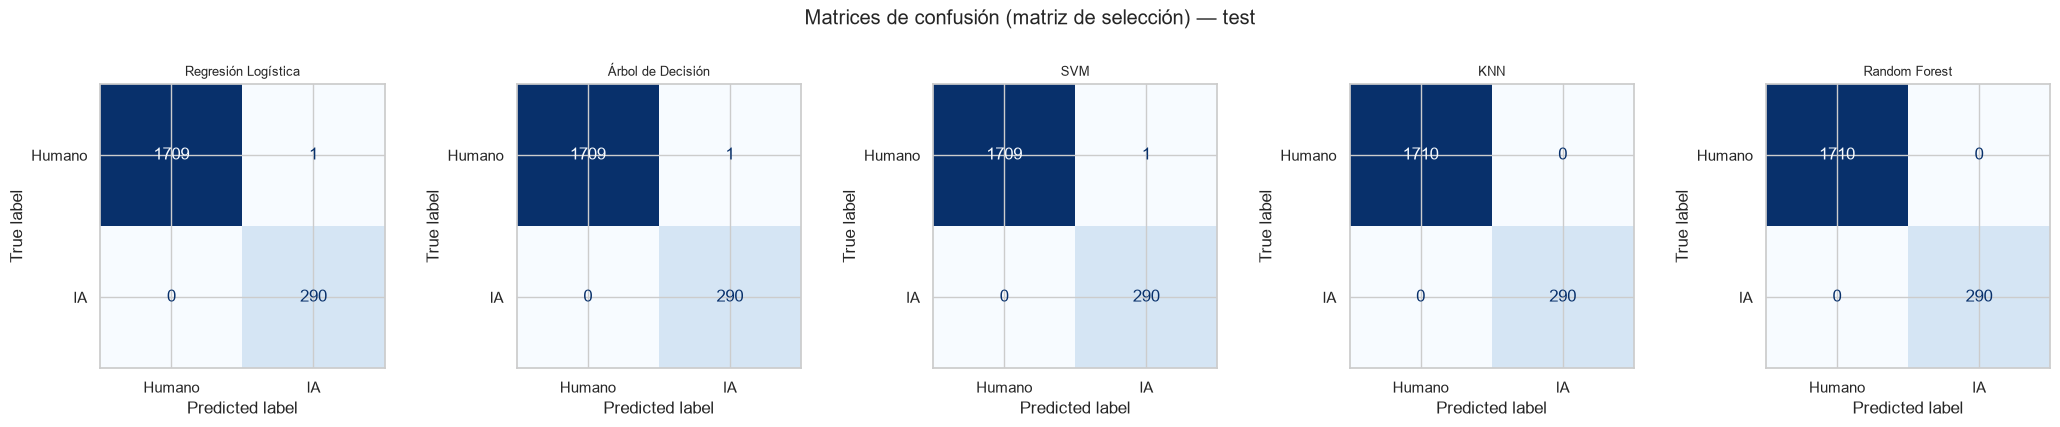

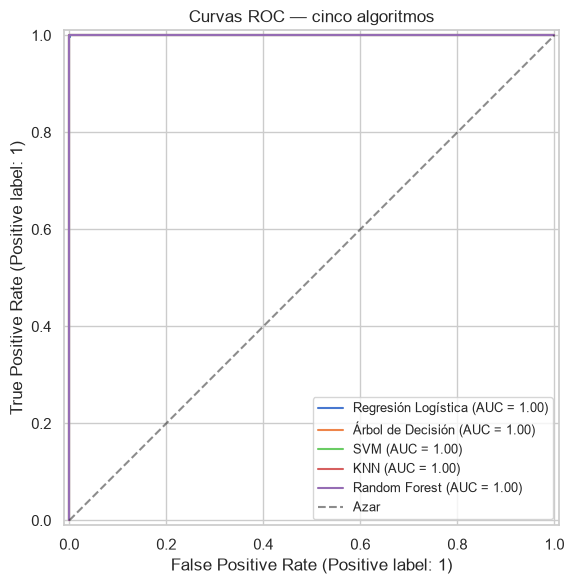

Mejor por F1 CV: SVM (1.0000).
Test: F1 IA=0.9983, recall IA=1.0000, ROC AUC=1.0000.
Selección: se prioriza F1 CV por el desbalance; test se reserva para la evaluación final.


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score

modelos_dataset_ii = {
    nombre: (busqueda.best_estimator_, busqueda.best_score_)
    for nombre, busqueda in grid_searches_ii.items()
}

pipe_rf_ii = Pipeline([
    ('prep', clone(prep_ns)),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced_subsample',
        random_state=rs,
        n_jobs=-1
    ))
])
cv_rf_ii = cross_val_score(
    pipe_rf_ii, X_train, y_train, cv=cv, scoring='f1', n_jobs=1
)
pipe_rf_ii.fit(X_train, y_train)
modelos_dataset_ii['Random Forest'] = (pipe_rf_ii, cv_rf_ii)

predicciones_dataset_ii = {}
filas_dataset_ii = []
for nombre, (modelo, f1_cv) in modelos_dataset_ii.items():
    prediccion = modelo.predict(X_test)
    score = (modelo.predict_proba(X_test)[:, 1]
             if hasattr(modelo, 'predict_proba')
             else modelo.decision_function(X_test))
    predicciones_dataset_ii[nombre] = prediccion
    filas_dataset_ii.append({
        'Modelo': nombre,
        'F1 CV': np.mean(f1_cv),
        'Accuracy test': accuracy_score(y_test, prediccion),
        'Precision IA test': precision_score(y_test, prediccion),
        'Recall IA test': recall_score(y_test, prediccion),
        'F1 IA test': f1_score(y_test, prediccion),
        'ROC AUC test': roc_auc_score(y_test, score)
    })

resultados_dataset_ii = (
    pd.DataFrame(filas_dataset_ii)
    .set_index('Modelo')
    .sort_values('F1 CV', ascending=False)
)
print(f'Dataset: {len(df):,} registros, {X.shape[1]} features predictoras.')
print('Comparación de los cuatro modelos optimizados + Random Forest:')
display(resultados_dataset_ii.round(4))

fig, axes = plt.subplots(1, len(modelos_dataset_ii), figsize=(21, 4))
for ax, (nombre, prediccion) in zip(axes, predicciones_dataset_ii.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, prediccion,
        display_labels=['Humano', 'IA'],
        cmap='Blues', ax=ax, colorbar=False, values_format='d'
    )
    ax.set_title(nombre, fontsize=9)
fig.suptitle('Matrices de confusión (matriz de selección) — test', y=1.03)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for nombre, (modelo, _) in modelos_dataset_ii.items():
    RocCurveDisplay.from_estimator(
        modelo, X_test, y_test, ax=ax, name=nombre
    )
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Azar')
ax.set_title('Curvas ROC — cinco algoritmos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

mejor_dataset_ii = resultados_dataset_ii['F1 CV'].idxmax()
fila_mejor_ii = resultados_dataset_ii.loc[mejor_dataset_ii]
print(f'Mejor por F1 CV: {mejor_dataset_ii} ({fila_mejor_ii["F1 CV"]:.4f}).')
print(
    f"Test: F1 IA={fila_mejor_ii['F1 IA test']:.4f}, "
    f"recall IA={fila_mejor_ii['Recall IA test']:.4f}, "
    f"ROC AUC={fila_mejor_ii['ROC AUC test']:.4f}."
)
print('Selección: se prioriza F1 CV por el desbalance; test se reserva para la evaluación final.')

### Conclusión — Ejercicio 3

Por **F1 medio de validación cruzada**, se selecciona SVM (1.0000); en test obtiene F1 de IA = 0.9983, recall = 1.0000 y ROC AUC = 1.0000. KNN y Random Forest empatan con métricas perfectas en test, pero su F1 CV es 0.9996; con diferencias tan pequeñas no hay un ganador concluyente. Se prioriza SVM por su resultado CV y se reporta test como evaluación final. Las matrices de confusión y curvas ROC están arriba. **Advertencia:** el dataset es sintético y contiene señales de telemetría muy fuertes; estas métricas no validan un detector general de textos generados por IA en datos reales.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*